# SENTIMENT ANALYSIS: USING CONVOLUTIONAL NEURAL NETWORK

Though originally designed for computer vision, CNNs are also widely used for natural language processing. Simply put, just think of any text sequence as a one-dimensional image. In this way, one-dimensional CNNs can process local features such as 
$n$-grams in text.

In this section, we will use the `textCNN` model to demonstrate how to design a CNN architecture for representing single text.

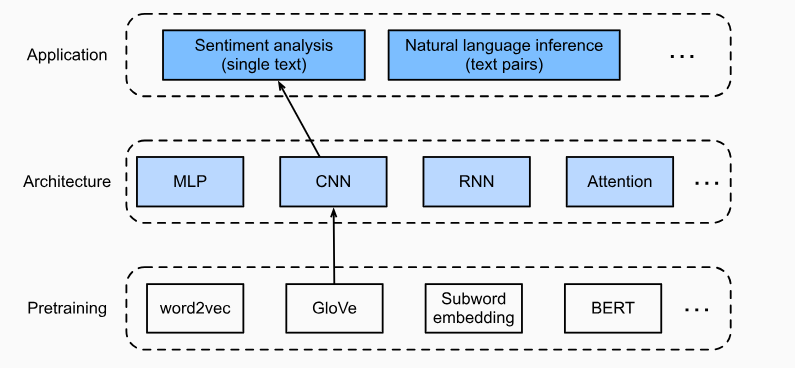

In [1]:
import torch
from torch import nn
from utils import spy

batch_size = 64
train_iter, test_iter, vocab = spy.load_data_imdb(batch_size)

c:\Users\DELL\.conda\envs\torch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Reading neg reviews: 100%|██████████| 12500/12500 [05:13<00:00, 39.85it/s]


## 1. One dimensional convolutions

Before introducing the model, let’s see how a one-dimensional convolution works. Bear in mind that it is just a special case of a two-dimensional convolution based on the cross-correlation operation.

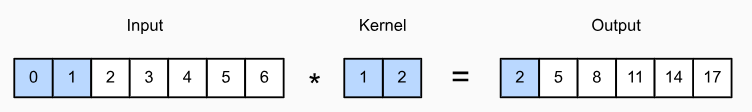

We implement one-dimensional cross-correlation in the following `corr1d` function. Given an input tensor X and a kernel tensor K, it returns the output tensor Y.



In [2]:
def corr1d(X, K):
    w = K.shape[0]
    Y = torch.zeros((X.shape[0] - w + 1))
    for i in range(Y.shape[0]):
        Y[i] = (X[i: i + w] * K).sum()
    return Y

We can construct the input tensor X and the kernel tensor K to validate the output of the above one-dimensional cross-correlation implementation.

In [3]:
X, K = torch.tensor([0, 1, 2, 3, 4, 5, 6]), torch.tensor([1, 2])
corr1d(X, K)

tensor([ 2.,  5.,  8., 11., 14., 17.])

For any one-dimensional input with multiple channels, the convolution kernel needs to have the same number of input channels. Then for each channel, perform a cross-correlation operation on the one-dimensional tensor of the input and the one-dimensional tensor of the convolution kernel, summing the results over all the channels to produce the one-dimensional output tensor. The figure below shows a one-dimensional cross-correlation operation with 3 input channels.



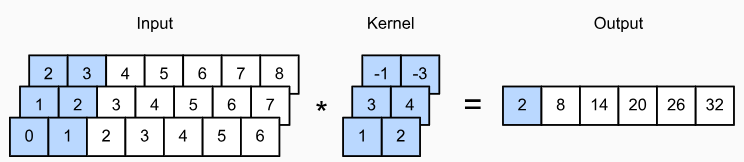

We can implement the one-dimensional cross-correlation operation for multiple input channels and validate the results.

In [4]:
def corr1d_multi_in(X, K):
    return sum(corr1d(x, k) for x, k in zip(X, K))

In [5]:
X = torch.tensor([[0, 1, 2, 3, 4, 5, 6],
              [1, 2, 3, 4, 5, 6, 7],
              [2, 3, 4, 5, 6, 7, 8]])
K = torch.tensor([[1, 2], [3, 4], [-1, -3]])
corr1d_multi_in(X, K)

tensor([ 2.,  8., 14., 20., 26., 32.])

## 2. Max-over-time pooling

Similarly, we can use pooling to extract the highest value from sequence representations as the most important feature across time steps. The max-over-time pooling used in textCNN works like the one-dimensional global max-pooling. For a multi-channel input where each channel stores values of different filters, the output at each channel is the maximum value for that channel. Note that the max-over-time pooling allows different numbers of time steps at different channels.

## 3. The textCNN Model

Using the one-dimensional convolution and max-over-time pooling, the textCNN model takes individual pretrained token representations as input, then obtains and transforms sequence representations for the downstream application.



For a single text sequence with $n$ tokens represented by 
$d$-dimensional vectors, the width, height, and number of channels of the input tensor are 
$n$, $1$, and $d$, respectively. The textCNN model transforms the input into the output as follows:

1. Define multiple one-dimensional convolution kernels and perform convolution operations separately on the inputs. Convolution kernels with different widths may capture local features among different numbers of adjacent tokens.

2. Perform max-over-time pooling on all the output channels, and then concatenate all the scalar pooling outputs as a vector.

3. Transform the concatenated vector into the output categories using the fully connected layer. Dropout can be used for reducing overfitting.

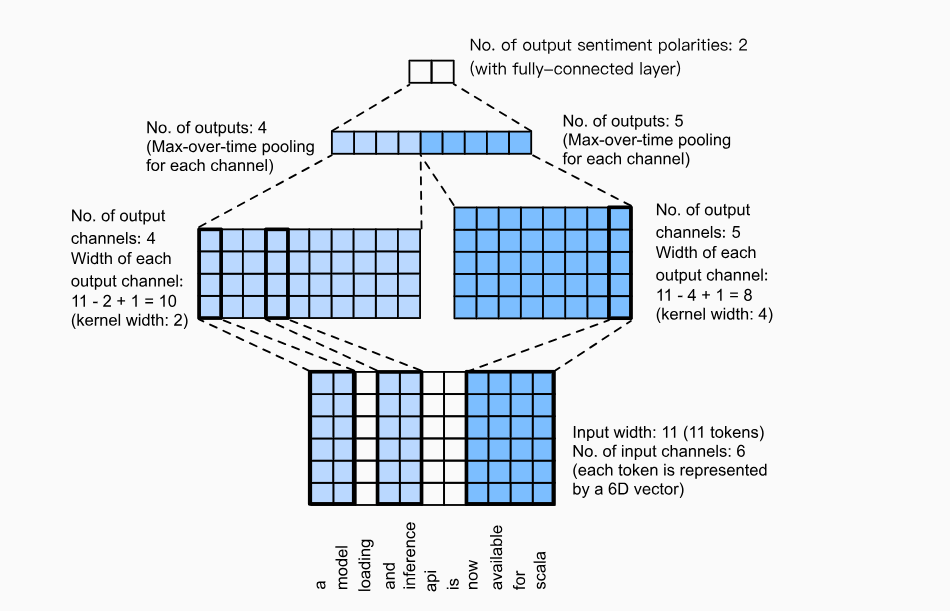

### 3.1. Defining the model

We implement the textCNN model in the following class. We also use two embedding layers: one with trainable weights and the other with fixed weights.

In [6]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.decoder = nn.Linear(sum(num_channels), 2)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.relu = nn.ReLU()
        # Create multiple one-dimensional convolutional layers
        self.convs = nn.ModuleList()
        for c, k in zip(num_channels, kernel_sizes):
            # conv in convs shape: (in_channels, out_channels, kernel_size)
            self.convs.append(nn.Conv1d(2 * embed_size, c, k))


    def forward(self, inputs):
        embeddings = torch.cat((
            self.embedding(inputs), self.constant_embedding(inputs)), dim=2)
        # Inputs of one-dimensional convolutional layer: (batch_size, num_channels, seq_len)
        # Therefore, we need to permute the order of axes
        embeddings = embeddings.permute(0, 2, 1)
        outs = torch.cat([torch.squeeze(self.relu(self.pool(conv(embeddings))), dim=-1) 
                          for conv in self.convs], dim=1)
        outputs = self.decoder(self.dropout(outs))
        return outputs 

Let’s create a textCNN instance. It has 3 convolutional layers with kernel widths of 3, 4, and 5, all with 100 output channels.

In [7]:
embed_size, kernel_sizes, num_channels = 100, [3, 4, 5], [100, 100, 100]
devices = spy.try_all_gpus()
net = TextCNN(len(vocab), embed_size, kernel_sizes, num_channels)

def init_weights(module):
    if type(module) in (nn.Linear, nn.Conv1d):
        nn.init.xavier_uniform_(module.weight)

net.apply(init_weights)

TextCNN(
  (embedding): Embedding(49346, 100)
  (constant_embedding): Embedding(49346, 100)
  (dropout): Dropout(p=0.5, inplace=False)
  (decoder): Linear(in_features=300, out_features=2, bias=True)
  (pool): AdaptiveMaxPool1d(output_size=1)
  (relu): ReLU()
  (convs): ModuleList(
    (0): Conv1d(200, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(200, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(200, 100, kernel_size=(5,), stride=(1,))
  )
)

### 3.2. Loading pretrained word vectors

We load pretrained 100-dimensional GloVe embeddings as the initialized token representations. These token representations (embedding weights) will be trained in embedding and fixed in constant_embedding.

In [8]:
glove_embedding = spy.TokenEmbedding('http://d2l-data.s3-accelerate.amazonaws.com/glove.6B.100d.zip')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

### 3.3. Training and evaluating the model

Now we can train the textCNN model for sentiment analysis.



Train loss: 0.094
Train acc: 0.967
Test acc: 0.868


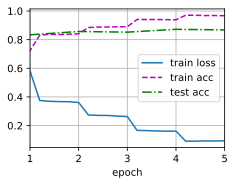

In [9]:
lr, num_epochs = 0.001, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction='none')
spy.train(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

Below we use the trained model to predict the sentiment for two simple sentences.



In [25]:
spy.predict_sentiment(net, vocab, 'this movie is not my cup of tea. i would never watch it a second time')

'positive'

In [11]:
spy.predict_sentiment(net, vocab, 'this movie is so bad')

'negative'